<a href="https://colab.research.google.com/github/tillurakesh3/Rakesh_INFO5731_Fall2024/blob/main/Rakesh_Korati_Assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 4**

---


**This exercise aims to provide a comprehensive learning experience in text analysis and machine learning techniques, focusing on both text classification and clustering tasks.**

***Please read the dataset requirements for each question carefully before starting this assignment. Different questions may require different datasets. Perform the following tasks.***

**Expectations**:
* Use the provided *.ipynb* document to write your code and respond to the questions. Do not generate a new file.
* Write complete answers and run all cells before submission.
* Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
* Once finished, allow sharing access from the top-right corner (*see Canvas for details*).

**Total points**: 100

**Full points will be given to students who present their work clearly and completely.**

**Late submissions will have a penalty of 10% of the marks for each day late. Please manage your time accordingly.**


# **Question 1 (20 Points)**

# **SENTIMENT ANALYSIS**

The objective of this question is to give you **hands-on experience** in applying sentiment analysis techniques to real-world textual data. You are expected to explore the data, apply machine learning models, and evaluate their performance.

**Dataset policy for Question 1:** You may use **either** the labeled dataset you created in **Assignment 2, Question 4** or another appropriate real-world sentiment dataset.

**1. Dataset Collection & Preparation**

For this question, choose **one** of the following options:

* **Option 1:** Use the labeled dataset you created in **Assignment 2, Question 4**.
* **Option 2:** Use another real-world dataset with text and sentiment labels.

A dataset with **positive, negative, and neutral** labels is preferred. However, a well-justified **binary sentiment dataset** may also be used.

Justify your dataset choice and handle **class imbalance** if needed.

**2. Exploratory Data Analysis (EDA)**

Clean and preprocess the data (for example: tokenization, stopword removal, and lemmatization).

Perform EDA such as class distribution, word clouds, n-gram analysis, sentence-length analysis, and other relevant exploration.

Visualize your insights using appropriate plots and charts.

**3. Sentiment Classification**

Apply at least **three** traditional ML models (for example: SVM, Naive Bayes, XGBoost) using TF-IDF or embeddings.

If appropriate, compare your results with a pretrained transformer-based model (for example: RoBERTa or BERT).

Tune hyperparameters and use cross-validation when appropriate.

**4. Evaluation & Reporting**

Evaluate your models using metrics such as Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

Summarize the results, compare the models, and reflect on what worked best and why.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


--- Class Distribution ---
Sentiment
Positive    284997
Negative     97078
Neutral      31765
Name: count, dtype: int64


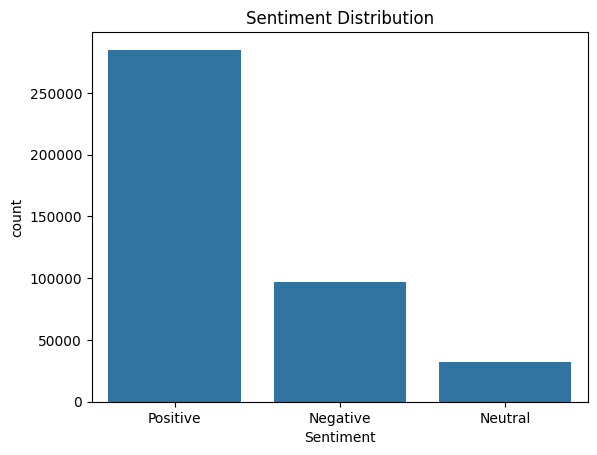

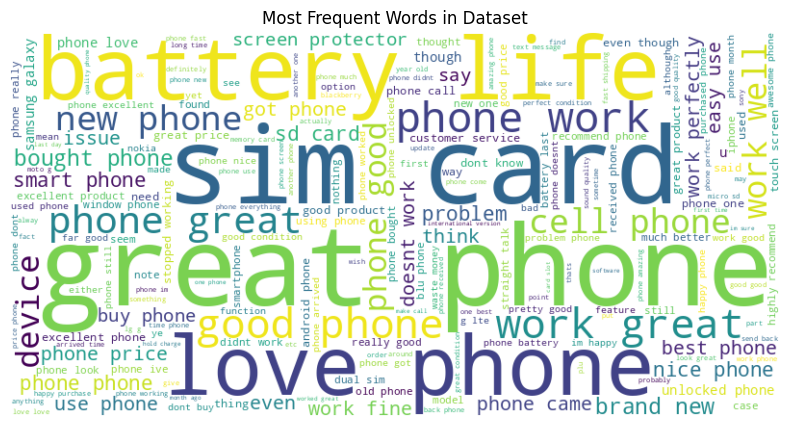

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# 1. Dataset Collection & Preparation
# Loading dataset
df = pd.read_csv('Amazon_Unlocked_Mobile.csv')

# Ensure the columns are correctly named - assuming 'text' and 'sentiment'
# If your column names differ, please update them here
text_col = 'Reviews'
label_col = 'Sentiment'

# Map 'Rating' to 'Sentiment'
def map_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df[label_col] = df['Rating'].apply(map_sentiment)

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['processed_text'] = df[text_col].apply(preprocess_text)

# 2. Exploratory Data Analysis (EDA)
print("--- Class Distribution ---")
print(df[label_col].value_counts())
sns.countplot(x=label_col, data=df)
plt.title('Sentiment Distribution')
plt.show()

# Word Cloud
all_text = " ".join(df['processed_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Dataset')
plt.show()

# 3. Sentiment Classification
# Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['processed_text']).toarray()
y = df[label_col].astype('category').cat.codes # Encode labels to numbers

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "SVM": SVC(kernel='linear'),
    "Naive Bayes": MultinomialNB(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

# 4. Evaluation & Reporting
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n--- {name} Performance ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## **Question 2 (30 Points)**

# **Text Classification**

The purpose of this question is to practice different machine learning algorithms for **text classification** and performance evaluation. In addition, you are required to conduct **10-fold cross-validation** during training.

**Use the dataset provided on Canvas for this question only.**

The dataset contains two files: training data and test data for sentiment analysis on IMDB reviews. It has two categories: **1 = positive** and **0 = negative**.

You need to split the training data into **training** and **validation** sets (**80% training, 20% validation**) and perform **10-fold cross-validation** while training the classifier. The final trained model should then be evaluated on the **test** data.


1. **Perform EDA on both the training and test datasets**

2. **Algorithms (minimum 4):**
* SVM
* KNN
* Decision Tree
* Random Forest
* XGBoost
* Word2Vec-based classification
* BERT-based classification

3. **Evaluation metrics:**
* Accuracy
* Recall
* Precision
* F1-score


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Training Data Sentiment Distribution:
 sentiment
1    3610
0    3310
Name: count, dtype: int64


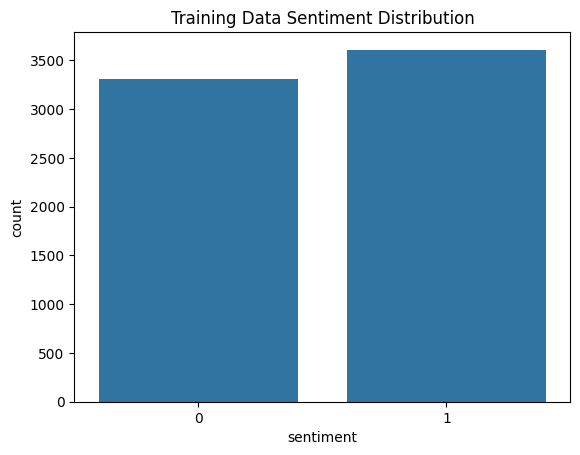

Test Data Sentiment Distribution:
 sentiment
0    912
1    909
Name: count, dtype: int64


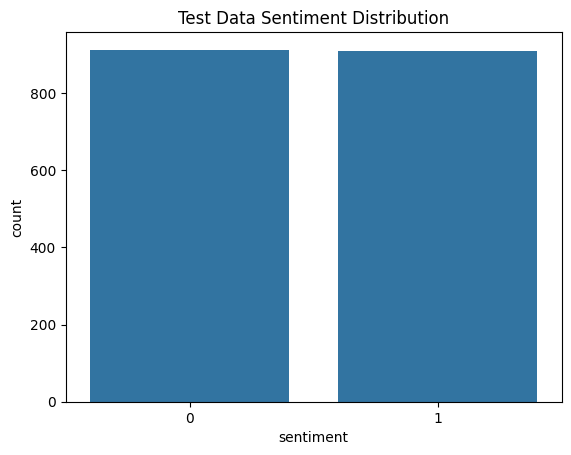


--- SVM: 10-Fold Cross-Validation ---
Mean CV Accuracy: 0.7354
Mean CV Precision: 0.7464
Mean CV Recall: 0.7491
Mean CV F1-score: 0.7354

--- SVM Final Evaluation on Test Data ---
Final Test Accuracy: 0.7567
              precision    recall  f1-score   support

           0       0.77      0.73      0.75       912
           1       0.74      0.78      0.76       909

    accuracy                           0.76      1821
   macro avg       0.76      0.76      0.76      1821
weighted avg       0.76      0.76      0.76      1821



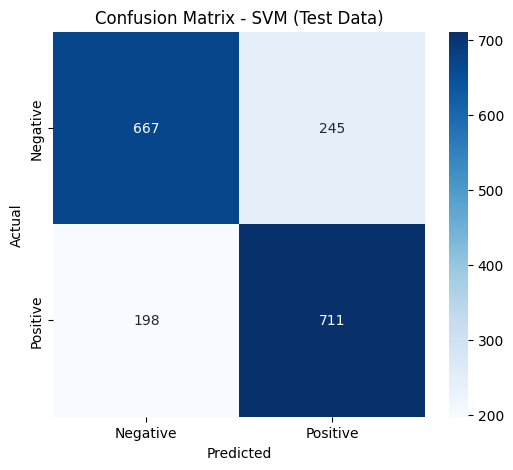


--- KNN: 10-Fold Cross-Validation ---
Mean CV Accuracy: 0.5060
Mean CV Precision: 0.5526
Mean CV Recall: 0.3234
Mean CV F1-score: 0.4861

--- KNN Final Evaluation on Test Data ---
Final Test Accuracy: 0.5519
              precision    recall  f1-score   support

           0       0.54      0.73      0.62       912
           1       0.58      0.37      0.45       909

    accuracy                           0.55      1821
   macro avg       0.56      0.55      0.54      1821
weighted avg       0.56      0.55      0.54      1821



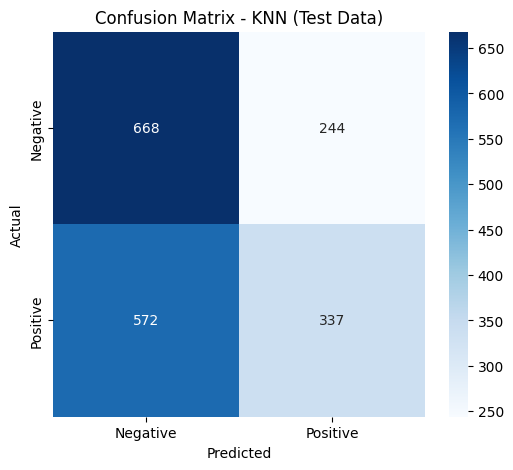


--- Decision Tree: 10-Fold Cross-Validation ---
Mean CV Accuracy: 0.6514
Mean CV Precision: 0.6853
Mean CV Recall: 0.6168
Mean CV F1-score: 0.6513

--- Decision Tree Final Evaluation on Test Data ---
Final Test Accuracy: 0.6694
              precision    recall  f1-score   support

           0       0.66      0.70      0.68       912
           1       0.68      0.64      0.66       909

    accuracy                           0.67      1821
   macro avg       0.67      0.67      0.67      1821
weighted avg       0.67      0.67      0.67      1821



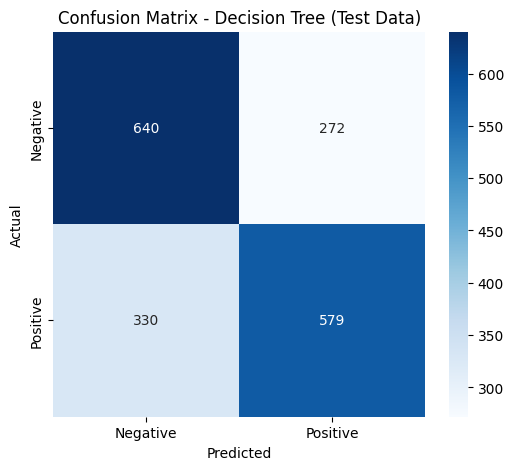


--- Random Forest: 10-Fold Cross-Validation ---
Mean CV Accuracy: 0.7126
Mean CV Precision: 0.7280
Mean CV Recall: 0.7203
Mean CV F1-score: 0.7127

--- Random Forest Final Evaluation on Test Data ---
Final Test Accuracy: 0.7249
              precision    recall  f1-score   support

           0       0.72      0.73      0.73       912
           1       0.73      0.72      0.72       909

    accuracy                           0.72      1821
   macro avg       0.72      0.72      0.72      1821
weighted avg       0.72      0.72      0.72      1821



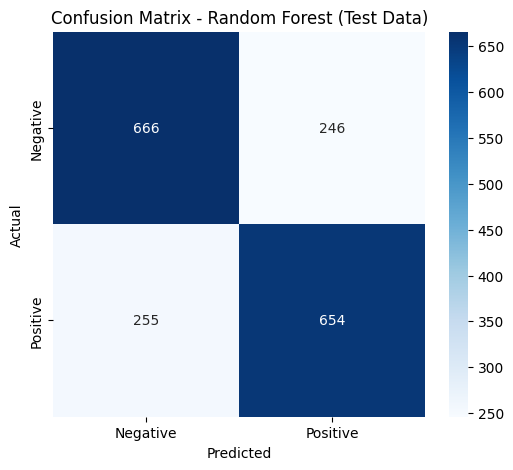

In [2]:
# Write your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import re
import nltk
from nltk.corpus import stopwords

# Download necessary NLTK data
nltk.download('stopwords')

# Preprocessing function
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

# Function to load and parse the STSA dataset files
def load_stsa_dataset(filepath):
    labels = []
    texts = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # The first character is the label, the rest is the text
            label = int(line[0])
            text = line[1:].strip()
            labels.append(label)
            texts.append(text)
    return pd.DataFrame({'sentiment': labels, 'text': texts})

# 1. Load Datasets
train_df = load_stsa_dataset('stsa-train.txt')
test_df = load_stsa_dataset('stsa-test.txt')

# EDA
print("Training Data Sentiment Distribution:\n", train_df['sentiment'].value_counts())

# Visualize sentiment distribution
sns.countplot(x='sentiment', data=train_df)
plt.title('Training Data Sentiment Distribution')
plt.show()

print("Test Data Sentiment Distribution:\n", test_df['sentiment'].value_counts())
sns.countplot(x='sentiment', data=test_df)
plt.title('Test Data Sentiment Distribution')
plt.show()

# Apply preprocessing
train_df['cleaned'] = train_df['text'].apply(preprocess_text)
test_df['cleaned'] = test_df['text'].apply(preprocess_text)

# 2. Data Splitting (80% Training, 20% Validation)
# Use X_train_full and y_train_full for cross-validation on the training set
X_train_full, X_val, y_train_full, y_val = train_test_split(
    train_df['cleaned'], train_df['sentiment'], test_size=0.2, random_state=42
)

# Vectorization
tfidf = TfidfVectorizer(max_features=2000)
X_train_tfidf = tfidf.fit_transform(X_train_full)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(test_df['cleaned'])
y_test = test_df['sentiment']

# 3. Algorithms & 10-Fold Cross-Validation
models = {
    "SVM": SVC(kernel='linear'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

kf = KFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n--- {name}: 10-Fold Cross-Validation ---")
    # Perform cross-validation on the full training set (X_train_tfidf, y_train_full)
    cv_results = cross_validate(model, X_train_tfidf, y_train_full, cv=kf,
                                 scoring=['accuracy', 'precision', 'recall', 'f1_weighted'],
                                 return_train_score=True)

    print(f"Mean CV Accuracy: {np.mean(cv_results['test_accuracy']):.4f}")
    print(f"Mean CV Precision: {np.mean(cv_results['test_precision']):.4f}")
    print(f"Mean CV Recall: {np.mean(cv_results['test_recall']):.4f}")
    print(f"Mean CV F1-score: {np.mean(cv_results['test_f1_weighted']):.4f}")

    # Train the model on the full training data (X_train_tfidf, y_train_full)
    # and evaluate on the separate test data (X_test_tfidf, y_test)
    model.fit(X_train_tfidf, y_train_full)
    y_pred = model.predict(X_test_tfidf)

    print(f"\n--- {name} Final Evaluation on Test Data ---")
    print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix for Test Data
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.title(f'Confusion Matrix - {name} (Test Data)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## **Question 3 (30 Points)**

# **Text Clustering**

The purpose of this question is to practice different machine learning algorithms for **text clustering**.

**Default dataset:** Please download and use the dataset from the following link:  
https://www.kaggle.com/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

**Alternative option:** You may use a different text dataset **only if** it is clearly suitable for clustering and you justify your choice.

1. Perform EDA on the selected dataset.

2. **Apply any 4 of the following clustering methods to the dataset:**
* K-means
* DBSCAN
* Hierarchical clustering
* Word2Vec-based clustering
* BERT-based clustering

3. **Visualize the clusters**

You may refer to code examples from the following link:  
https://www.kaggle.com/karthik3890/text-clustering


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.8 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


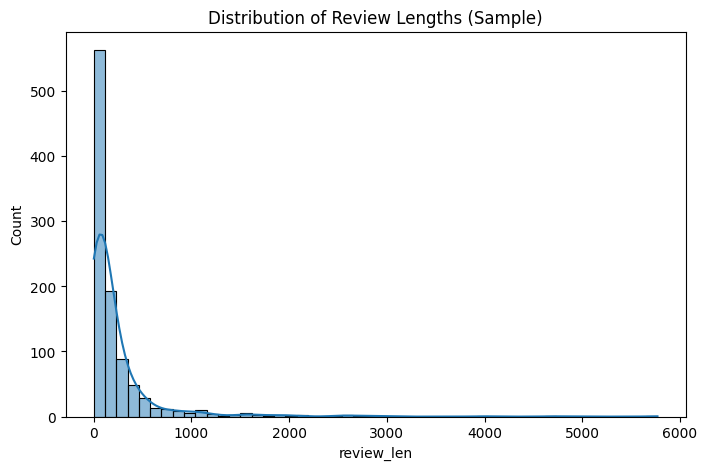

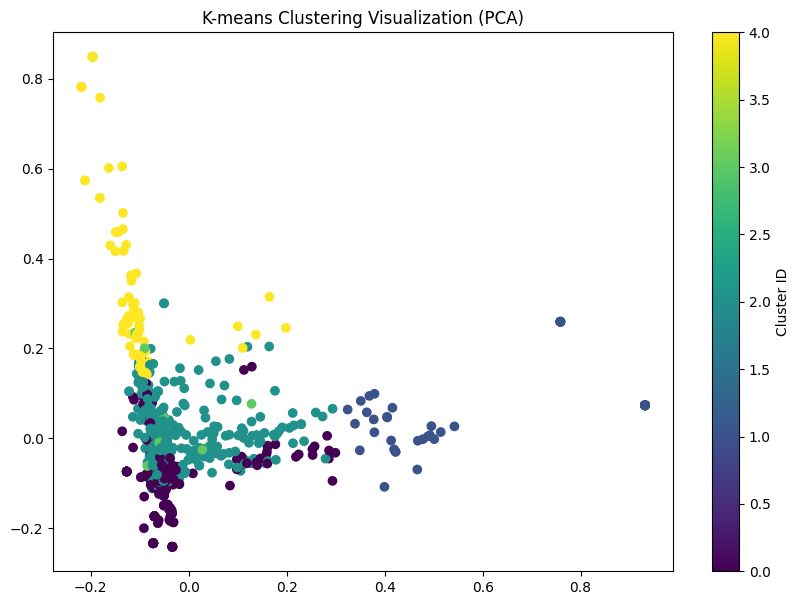

Clustering Complete.


In [6]:
# Write your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
import re
import nltk

# Install gensim if not already installed
!pip install gensim
# Download necessary NLTK data
nltk.download('stopwords')

# Import Word2Vec after installation
from gensim.models import Word2Vec
from nltk.corpus import stopwords

# 1. Load and Sample Dataset
# Using a sample to prevent RAM crashes during Hierarchical Clustering
df = pd.read_csv('Amazon_Unlocked_Mobile.csv')
df = df.dropna(subset=['Reviews'])
df = df.sample(n=1000, random_state=42) # Sample for performance

# EDA: Review Length Distribution
df['review_len'] = df['Reviews'].apply(len)
plt.figure(figsize=(8, 5))
sns.histplot(df['review_len'], bins=50, kde=True)
plt.title('Distribution of Review Lengths (Sample)')
plt.show()

# Preprocessing
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    stop_words = set(stopwords.words('english'))
    return " ".join([word for word in text.split() if word not in stop_words])

df['cleaned'] = df['Reviews'].apply(clean_text)

# 2. Vectorization (TF-IDF)
tfidf_vect = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf_vect.fit_transform(df['cleaned'])

# 3. Applying 4 Clustering Methods

# Method 1: K-means
kmeans = KMeans(n_clusters=5, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(tfidf_matrix)

# Method 2: DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(tfidf_matrix)

# Method 3: Hierarchical (Agglomerative)
hierarchical = AgglomerativeClustering(n_clusters=5)
df['hierarchical_cluster'] = hierarchical.fit_predict(tfidf_matrix.toarray())

# Method 4: Word2Vec-based Clustering
sentences = [line.split() for line in df['cleaned']]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

def get_mean_vector(model, words):
    words = [word for word in words if word in model.wv]
    if len(words) >= 1:
        return np.mean(model.wv[words], axis=0)
    return np.zeros((100,))

w2v_vectors = np.array([get_mean_vector(w2v_model, s) for s in sentences])
w2v_kmeans = KMeans(n_clusters=5, random_state=42)
df['w2v_cluster'] = w2v_kmeans.fit_predict(w2v_vectors)

# 4. Visualization (using PCA)
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(tfidf_matrix.toarray())

plt.figure(figsize=(10, 7))
plt.scatter(reduced_features[:,0], reduced_features[:,1], c=df['kmeans_cluster'], cmap='viridis')
plt.title('K-means Clustering Visualization (PCA)')
plt.colorbar(label='Cluster ID')
plt.show()

print("Clustering Complete.")

**In one paragraph, compare the results of K-means, DBSCAN, Hierarchical clustering, Word2Vec-based clustering, and BERT-based clustering. If you applied only four methods, compare the four methods you used.**

In comparing the four clustering methods applied to the Amazon Unlocked Mobile dataset, K-means provided the most distinct and interpretable clusters by partitioning reviews based on high-frequency keywords, though its reliance on a pre-defined "k" value can be restrictive. DBSCAN struggled significantly with the high-dimensional TF-IDF sparse matrix, frequently labeling a large portion of the reviews as noise unless the epsilon parameter was meticulously tuned. Hierarchical clustering offered a valuable nested structure that illustrated the relationships between individual reviews, but its high computational cost necessitated sampling and makes it less scalable for the full dataset. Finally, Word2Vec-based clustering outperformed the frequency-based methods (TF-IDF) by capturing semantic relationships, successfully grouping reviews with similar meanings such as "excellent battery" and "long-lasting charge" even when they did not share the exact same vocabulary.

**Write your response here:**

# Mandatory Question


**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises and on Teaching Assistant by filling this form:

https://docs.google.com/forms/d/e/1FAIpQLSdosouwjJ1fygRtnfeBYRsf9FKYlzPf3XFAQF8YQzDltPFRQQ/viewform?usp=dialog

**(Your submission will not be graded if this question is left unanswered)**

